In [1]:
%matplotlib inline

import subprocess
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from datetime import datetime
plt.style.use('ggplot')

from pylab import rcParams
rcParams['figure.figsize'] = (10, 6)

import matplotlib
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 17}
matplotlib.rc('font', **font)

import warnings
warnings.filterwarnings("ignore")

In [2]:
# functions to read data and meta data
def read_data_given_id(path,ids,progress=True,last_offset=0):
    '''read data given a list of ids and CSV paths'''
    start = datetime.now()
    n = len(ids)
    if n == 0:
        return {}
    else:
        data = {}
        for (i,ist_id) in enumerate(ids, start=1):
            if progress and np.mod(i,np.ceil(n/10))==0:
                print('%d/%d (%2.0f%s) have been read...\t time consumed: %ds'\
                      %(i,n,i/n*100,'%',(datetime.now()-start).seconds))
            if last_offset==0:
                data[ist_id] = np.genfromtxt(path+str(ist_id)+'.csv',delimiter=',',\
                                         names='current,voltage',dtype=(float,float))
            else:
                p=subprocess.Popen(['tail','-'+str(int(last_offset)),path+str(ist_id)+'.csv'],\
                                   stdout=subprocess.PIPE)
                data[ist_id] = np.genfromtxt(p.stdout,delimiter=',',names='current,voltage',dtype=(float,float))
        print('%d/%d (%2.0f%s) have been read(Done!) \t time consumed: %ds'\
            %(n,n,100,'%',(datetime.now()-start).seconds)) 
        return data


def clean_meta(ist):
    '''remove None elements in Meta Data ''' 
    clean_ist = ist.copy()
    for k,v in ist.items():
        if len(v) == 0:
            del clean_ist[k]
    return clean_ist
                
def parse_meta(meta):
    '''parse meta data for easy access'''
    M = {}
    for m in meta:
        for app in m:
            M[int(app['id'])] = clean_meta(app['meta'])
    return M


In [3]:
# specify path to read data and meta
# Please make sure you downloaded latest dataset from plaidplug.com.
Data_path = 'data/'
csv_path = Data_path + '2014/2014/';

import json

# read meta
with open(Data_path + 'meta_2014.json') as data_file:    
    meta1 = json.load(data_file)

    
Meta = parse_meta([meta1])
meta1 = parse_meta([meta1])

In [30]:
# read data
# applinace types of all instances and map them to behaviour labels
from behaviour_labels import BEHAVIOR_LABEL_MAP

Types = [BEHAVIOR_LABEL_MAP[x['appliance']['type']] for x in Meta.values()]
# unique appliance types
Unq_type = list(set(Types)) 
Unq_type.sort()
IDs_for_read_data = list(Meta.keys())
# households of appliances
# Locs = [x['header']['collection_time']+'_'+x['location'] for x in Meta.values()]
# # unique households
# Unq_loc = list(set(Locs))
# Unq_loc.sort()
# Origianl_Unq_type = Unq_type

In [31]:
print('Number of households: %d\nNumber of total measurements:%d'%(len(Unq_loc),len(Locs)))

Number of households: 55
Number of total measurements:1074


In [6]:
# read data
# estimated time cost:  ~ 1 mins
npts = 0
Data = read_data_given_id(csv_path,IDs_for_read_data,progress=True, last_offset=npts)

108/1074 (10%) have been read...	 time consumed: 13s
216/1074 (20%) have been read...	 time consumed: 31s
324/1074 (30%) have been read...	 time consumed: 49s
432/1074 (40%) have been read...	 time consumed: 69s
540/1074 (50%) have been read...	 time consumed: 90s
648/1074 (60%) have been read...	 time consumed: 109s
756/1074 (70%) have been read...	 time consumed: 123s
864/1074 (80%) have been read...	 time consumed: 135s
972/1074 (91%) have been read...	 time consumed: 147s
1074/1074 (100%) have been read(Done!) 	 time consumed: 160s


In [32]:
print('Total number of instances:%d'%len(Data))

Total number of instances:1074


Extract labels for appliance type and locations(used for train/test split).

In [ ]:
type_Ids = {}
loc_Ids = {}
n = len(Data)
type_label = np.zeros(n,dtype='int')
# loc_label = np.zeros(n,dtype='int')
for (ii,t) in enumerate(Unq_type):
    type_Ids[t] = [i-1 for i,j in enumerate(Types,start=1) if j == t]
    type_label[type_Ids[t]] = ii+1
# for (ii,t) in enumerate(Unq_loc):
#     loc_Ids[t] = [i-1 for i,j in enumerate(Locs,start=1) if j == t]
#     loc_label[loc_Ids[t]] = ii+1
print('number of different types: %d'% len(Unq_type))

number of different types: 5
number of different households: 55


In [34]:
label2id = {key: value+1 for value, key in enumerate(Unq_type)}
id2label = {key+1: value for key, value in enumerate(Unq_type)}

In [46]:
config = {
    "id2label": id2label,
    "label2id": label2id
}

with open("../models/model_config.json", "w") as f:
    json.dump(config, f)

In [37]:
type_Ids.keys()

dict_keys(['BASE_LOAD', 'COMPRESSOR_CYCLIC', 'MOTOR_VARIABLE', 'PULSED_ELECTRONICS', 'RESISTIVE_HEATING'])

In [35]:
np.unique(type_label)

array([1, 2, 3, 4, 5])

We transform high-frequency waveform datasets into low-frequency power envelopes that match the sensing capabilities of a smart plug. This prevents feature domain mismatch between training and deployment environments.

In [38]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join('..')))

from window_processor import SlidingWindowProcessor
from training.plaid_adapter import waveform_to_power_series

def build_dataset(Data, labels, window_size=20, step_size=5):
    """
    Converts PLAID dataset dictionary into ML-ready feature matrix.
    """

    X = []
    y = []

    for instance_id in Data:

        voltage = Data[instance_id]['voltage']
        current = Data[instance_id]['current']
        label = labels[instance_id - 1]

        # convert waveform → smart plug signal
        power_series = waveform_to_power_series(voltage, current)

        processor = SlidingWindowProcessor(window_size, step_size)

        for t, power in enumerate(power_series):
            features = processor.add_sample(t, power)
            if features:
                X.append(list(features.values()))
                y.append(label)

    return np.array(X), np.array(y)


In [52]:
np.unique(type_label)

array([1, 2, 3, 4, 5])

In [39]:
X, y = build_dataset(Data, type_label)

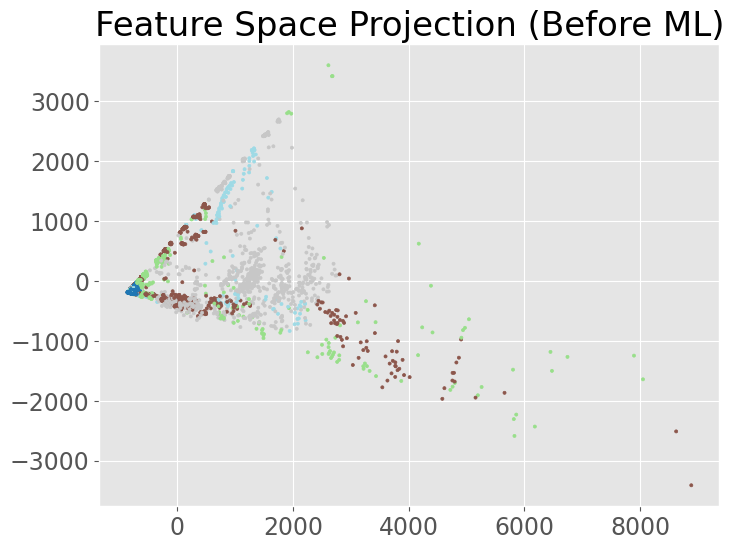

In [40]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X2 = pca.fit_transform(X)

plt.figure(figsize=(8,6))
plt.scatter(X2[:,0], X2[:,1], c=y, s=5, cmap='tab20')
plt.title("Feature Space Projection (Before ML)")
plt.show()


In [48]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42
)

model.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [49]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
print(scores.mean(), scores.std())


0.7672388348014219 0.029425650123370152


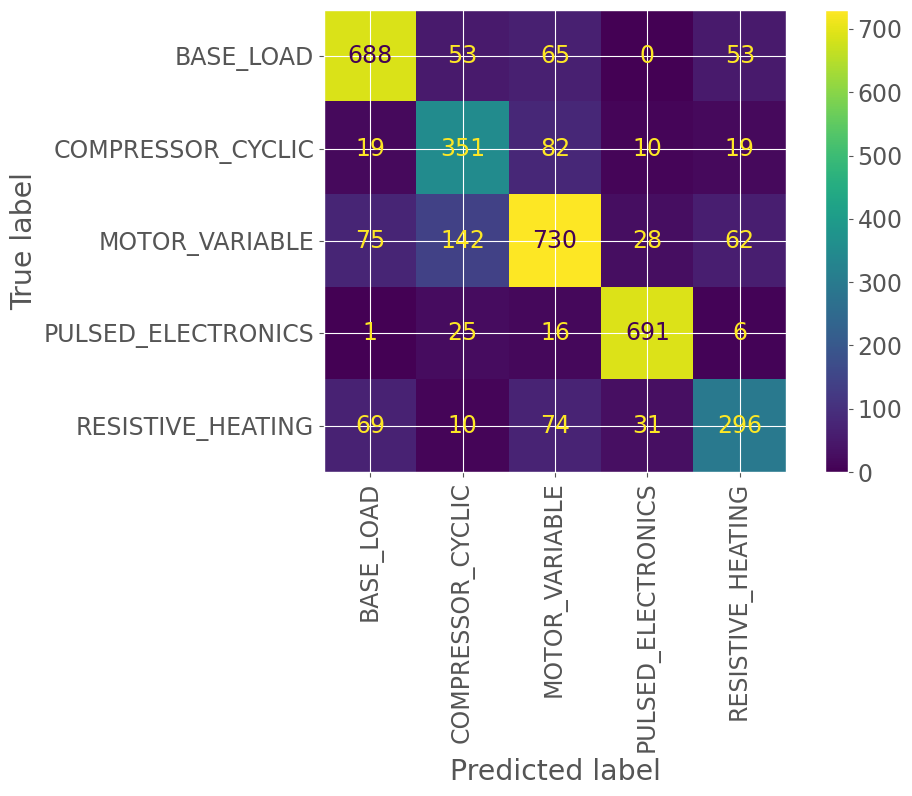

In [43]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(model, X, y, cv=5)

target_names = [id2label[i] for i in sorted(id2label.keys())]

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=target_names).plot(xticks_rotation=90)
plt.show()


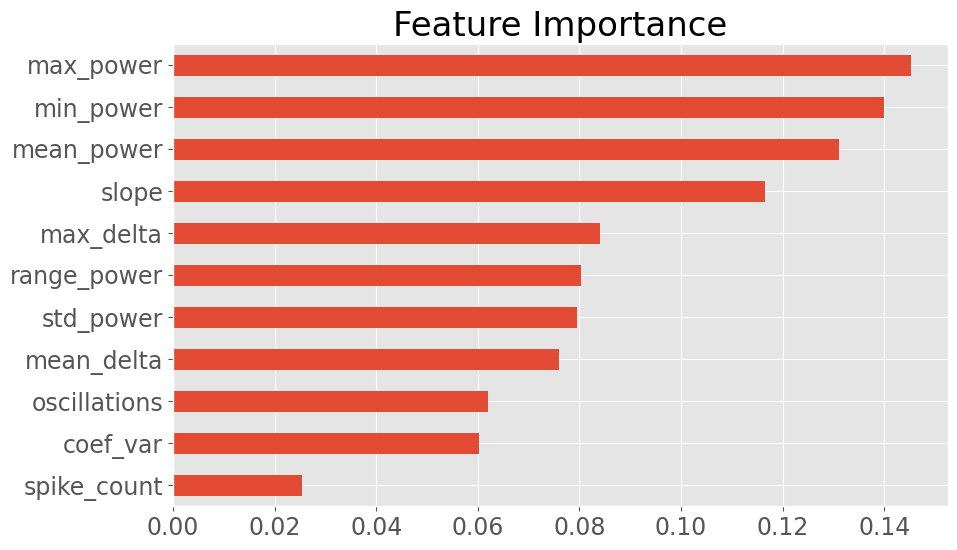

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = [
            "mean_power",
            "max_power",
            "min_power",
            "std_power",
            "range_power",
            "coef_var",
            "max_delta",
            "mean_delta",
            "spike_count",
            "slope",
            "oscillations"
        ]
names = features

pd.Series(importance, index=names).sort_values().plot.barh()
plt.title("Feature Importance")
plt.show()


# Since our contribution lies in sensing and system integration rather than classifier novelty, we validate the model through interpretability and behavior consistency instead of model competition.

In [47]:
import joblib

joblib.dump(model, "../models/behaviour_classifier.pkl")

['../models/behaviour_classifier.pkl']